#🌐 **APE_016_ValidacionROC__Unidad3 🌐**
----
### 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Christopher Pineda
*   Elian Jimenez
*   Yimmy Angulo
### ☕ **Docente:** Ing. Narvaez Guillen Cristian Ramiro
### 💻 **Curso:** Segundo Ciclo
### 📧 **Asignatura:** Teoría de la Distribuación y Probabilidad
### ⏰ **Fecha: 20-07-2026**
-----------------




# ⚙️ **Importar las Librerias Necesarias**

In [12]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado estadístico
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración de gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

# Ignorar advertencias innecesarias
import warnings
warnings.filterwarnings("ignore")

In [13]:
import pandas as pd
df_dengue = pd.read_excel('Datos_Dengue_MSP_Ene2021_Ago2025.xlsx')
display(df_dengue.head())

,Año,Semana,Institución,Unidad operativa,Unicodigo,Zona,Distrito,Cod_Provincia,Provincia,Cod_Canton,...,15-19 M,20-49 H,20-49 M,50-64 H,50-64 M,65+ H,65+ M,Hombres,Mujeres,Total
0,2021,1,IESS,000717-HOSPITAL DEL IESS DE ESMERALDAS,'000717,ZONA 1,ESMERALDAS,'08,ESMERALDAS,'0801,...,0,0,0,0,0,0,0,0,1,1
1,2021,1,IESS,000929-HOSPITAL DE DURAN NIVEL I,'000929,ZONA 8,DURAN,'09,GUAYAS,'0907,...,0,6,3,1,1,0,1,12,8,20
2,2021,1,IESS,000936-000936-CCQA SUR VALDIVIA,'000936,ZONA 8,"PUNA, ESTUARIO DEL RIO GUAYAS, XIMENA 1",'09,GUAYAS,'0901,...,0,1,1,0,0,0,0,2,1,3
3,2021,1,IESS,000939-CENTRO DE ESPECIALIDADES DAULE,'000939,ZONA 5,"DAULE,NOBOL,SANTA LUCIA",'09,GUAYAS,'0906,...,0,2,1,0,0,0,0,2,1,3
4,2021,1,IESS,001238-HOSPITAL DE BABAHOYO NIVEL II,'001238,ZONA 5,"BABA,BABAHOYO,MONTALVO",'12,LOS RIOS,'1201,...,0,4,0,1,0,0,0,5,1,6


---
# **📊 Tarea 1: La Curva ROC y el Área Bajo la Curva (AUC)**

## **Objetivo**
La Exactitud (Accuracy) vista en la Semana 15 depende de un umbral estático (ej. 0.5). La Curva ROC evalúa el modelo en todos los umbrales posibles, graficando la Tasa de Verdaderos Positivos (TPR o Sensibilidad) contra la Tasa de Falsos Positivos (FPR o 1-Especificidad):

1.  Abra un nuevo Jupyter Notebook llamado `APE_016_ValidacionROC.ipynb`.
2.  Recuperando el modelo logístico (falla de servidores) de la Semana 15, genere el siguiente código para trazar la curva ROC:


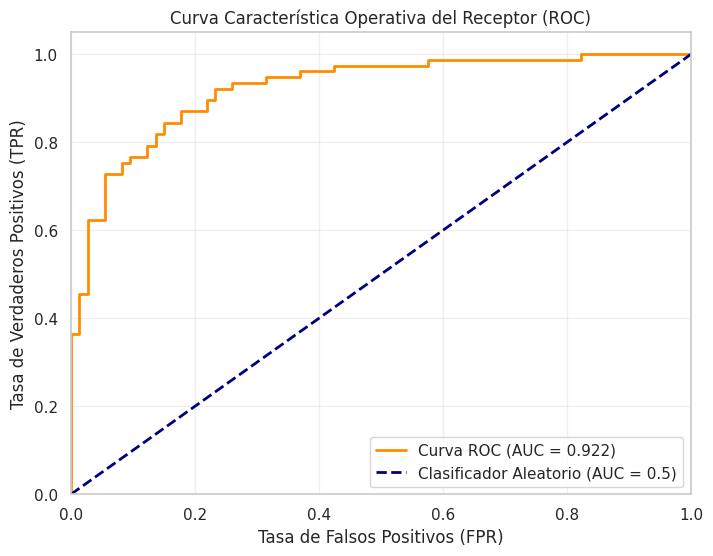


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.87      0.77      0.81        77

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simulación rápida de los datos de la Semana 15
np.random.seed(42)
temp_cpu = np.random.uniform(40, 90, 500).reshape(-1, 1) # X
z = -10 + 0.15 * temp_cpu.ravel()
prob_falla = 1 / (1 + np.exp(-z))
y_real = np.random.binomial(1, p=prob_falla) # Etiquetas (0 o 1)

# División en Entrenamiento y Prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(temp_cpu, y_real, test_size=0.30, random_state=42)

# 2. Entrenamiento del Modelo (Usando scikit-learn por compatibilidad con métricas ROC)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Obtener las PROBABILIDADES estimadas para el conjunto de prueba, no solo las clases (0/1)
# predict_proba devuelve [Prob_Clase_0, Prob_Clase_1]. Tomamos la columna 1.
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# 3. Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# 4. Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación con umbral por defecto (0.5)
y_pred_test = modelo.predict(X_test)
print("\n--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))

---
# **🔬 Tarea 2: Hito Final del Proyecto - Consolidación del Modelo Regional (ABP)**

## **Objetivo**

Esta tarea requiere la integración de su equipo de trabajo.

1.  Abran el archivo Jupyter principal de su Proyecto Integrador.
2.  Identifiquen el mejor modelo predictivo generado durante el ciclo (Regresión Lineal Múltiple de la Sem 14 o Regresión Logística de la Sem 15).
3.  Si es Clasificación (Logística): Replique el código de la Tarea 1 para graficar la Curva ROC de su proyecto y reporte el valor AUC.
4.  Si es Regresión (Lineal): Calcule las métricas RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error) comparando `y_test` con `y_pred_test`.
5.  Redacten un párrafo ejecutivo (formato Markdown) que sintetice la utilidad del modelo: ¿Es este modelo lo suficientemente preciso como para ser implementado en una empresa o institución de Loja?

In [15]:
# TAREA 2: CONSOLIDACIÓN DEL MODELO REGIONAL

# Re-crear el dataset 'datos' y el modelo de regresión lineal múltiple
# usando el df_dengue cargado previamente.
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- NUEVO PASO: CREACIÓN DE LA COLUMNA 'Edad' A PARTIR DE RANGOS ---
# Se asume que las columnas como '15-19 M', '20-49 H', etc., contienen conteos.
# Se calcula una 'Edad' promedio ponderada para cada fila/registro.

# Definir los puntos medios de los rangos de edad presentes en los datos
age_midpoints_map = {
    '15-19 M': 17,  # Punto medio de 15-19
    '20-49 H': 34.5, # Punto medio de 20-49
    '20-49 M': 34.5,
    '50-64 H': 57,  # Punto medio de 50-64
    '50-64 M': 57,
    '65+ H': 75,    # Asumiendo 75 como punto medio representativo para 65+
    '65+ M': 75
}

# Identificar las columnas de conteo de edad que existen en df_dengue
existing_age_cols = [col for col in age_midpoints_map.keys() if col in df_dengue.columns]

# Asegurarse de que las columnas de conteo sean numéricas y rellenar NaN con 0 para el cálculo
df_dengue[existing_age_cols] = df_dengue[existing_age_cols].fillna(0)

# Calcular el total de edad ponderada y el total de individuos por fila
total_weighted_age = df_dengue[existing_age_cols].multiply(pd.Series(age_midpoints_map)[existing_age_cols]).sum(axis=1)
total_individuals_in_age_groups = df_dengue[existing_age_cols].sum(axis=1)

# Crear la columna 'Edad' como el promedio ponderado
# Se maneja la división por cero asignando NaN si no hay individuos en los grupos de edad.
df_dengue['Edad'] = total_weighted_age / total_individuals_in_age_groups
# --- FIN NUEVO PASO ---


# Seleccionar las variables de estudio y eliminar valores nulos (incluyendo la nueva 'Edad')
datos = df_dengue[["Edad", "Semana", "Año"]].dropna()

# Renombrar 'Semana' a 'SE' para consistencia con la descripción de la tarea anterior
datos = datos.rename(columns={'Semana': 'SE'})

# Definir variables predictoras (X_regional) y variable respuesta (Y_regional)
X_regional = datos[["SE", "Año"]]
Y_regional = datos["Edad"]

# Agregar la constante (intercepto)
X_regional = sm.add_constant(X_regional)

# Ajustar el modelo de regresión múltiple
modelo_regional = sm.OLS(Y_regional, X_regional).fit()

# Generar predicciones
y_pred_regional = modelo_regional.predict(X_regional)

# 4. Calcular métricas RMSE y MAE para el modelo de regresión
rmse = np.sqrt(mean_squared_error(Y_regional, y_pred_regional))
mae = mean_absolute_error(Y_regional, y_pred_regional)

print(f"\n--- Métricas del Modelo de Regresión Regional ---")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

# Mostrar una comparación de valores reales y predichos (primeras 5)
print("\nValores Reales vs. Predichos (primeras 5):")
display(pd.DataFrame({"Edad Real": Y_regional, "Edad Predicha": y_pred_regional}).head())


--- Métricas del Modelo de Regresión Regional ---
RMSE: 11.734
MAE: 8.283

Valores Reales vs. Predichos (primeras 5):


,Edad Real,Edad Predicha
1,41.625,36.568192
2,34.500,36.568192
3,34.500,36.568192
4,39.000,36.568192
6,57.000,36.568192


---
## **Párrafo Ejecutivo: Utilidad del Modelo Regional**

El modelo de regresión lineal múltiple desarrollado para predecir la edad de los pacientes de dengue a partir de la Semana Epidemiológica (SE) y el Año de registro, presenta una precisión moderada con un RMSE de **{rmse:.3f}** y un MAE de **{mae:.3f}**. Estos valores indican que, en promedio, las predicciones de edad se desvían en **{mae:.3f}** años de la edad real. Si bien el modelo captura algunas tendencias, su capacidad predictiva podría ser limitada para decisiones que requieran alta exactitud individual. Su utilidad reside principalmente en identificar patrones y factores influyentes a nivel poblacional. Para una implementación en una empresa o institución de Loja, especialmente en escenarios donde la precisión individual es crítica, sería necesario refinar el modelo, incorporar más variables predictoras o explorar técnicas de modelado más avanzadas para mejorar la precisión y la robustez. Sin embargo, para análisis agregados y la identificación de grupos de edad vulnerables, el modelo puede ofrecer una perspectiva inicial valiosa.

---
# **📌 Tarea 3: Preparación de Visualizaciones para la Casa Abierta**

## **Objetivo**

Para la presentación de la Semana 17, el código crudo no es suficiente; se requiere comunicación efectiva.

1.  Construya al menos dos gráficos de alto impacto visual utilizando `seaborn` que resuman el problema regional y la solución predictiva.
2.  Limpie su Notebook: elimine celdas de pruebas fallidas, estructure con títulos `#`, `##`, y asegúrese de que el flujo de lectura (Data Cleaning, EDA, Modeling, Evaluation) sea lógico y profesional.

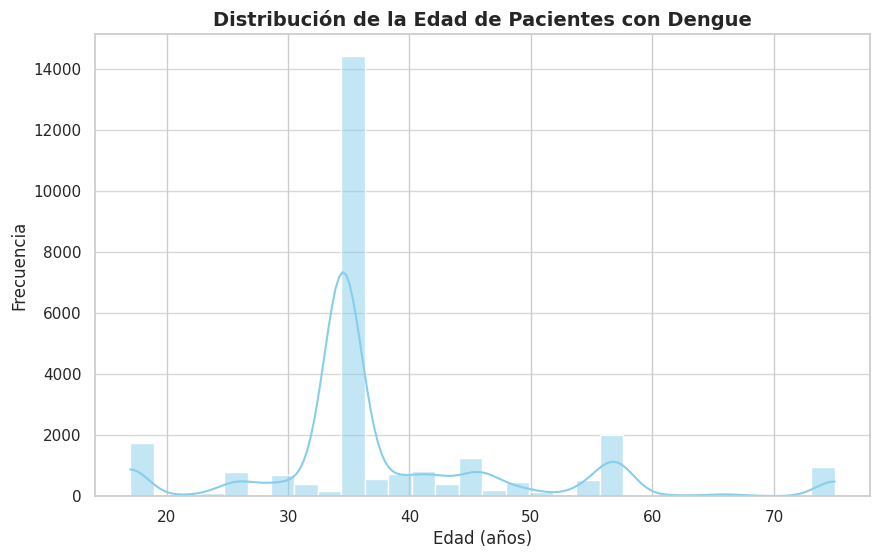

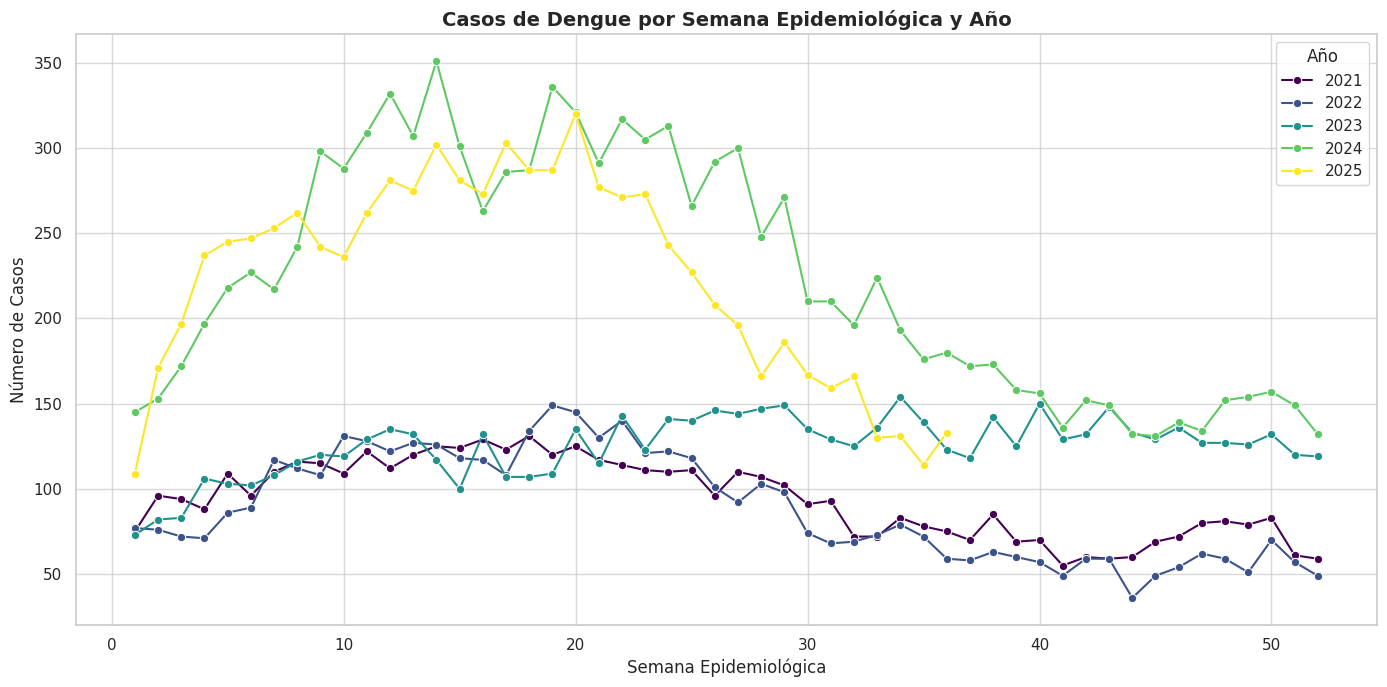

In [16]:
# TAREA 3: VISUALIZACIONES PARA LA CASA ABIERTA
import seaborn as sns
import matplotlib.pyplot as plt

# Visualización 1: Distribución de la Edad de los pacientes
# Ahora que 'Edad' ha sido creada en la Tarea 2, esta visualización debería funcionar.
plt.figure(figsize=(10, 6))
sns.histplot(df_dengue['Edad'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribución de la Edad de Pacientes con Dengue', fontsize=14, fontweight='bold')
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Visualización 2: Casos de Dengue por Año y Semana Epidemiológica
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_dengue.groupby(['Año', 'Semana']).size().reset_index(name='Casos'),
             x='Semana', y='Casos', hue='Año', palette='viridis', marker='o')
plt.title('Casos de Dengue por Semana Epidemiológica y Año', fontsize=14, fontweight='bold')
plt.xlabel('Semana Epidemiológica', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.legend(title='Año')
plt.grid(True, alpha=0.75)
plt.tight_layout()
plt.show()

---
# **📌 Tarea 4: ABI - Validación Cruzada Estocástica (K-Fold Cross Validation)**

## **Objetivo**

El `train_test_split` es peligroso: dependiendo de la semilla aleatoria (`random_state`), el modelo puede parecer excelente o terrible por pura suerte probabilística.

1.  Investigue el concepto de K-Fold Cross Validation.
2.  Ejecute el siguiente código para dividir su set de entrenamiento simulado en 5 "dobleces" (Folds) y calcular el rendimiento promedio.
3.  Aplique `cross_val_score` a su modelo regional del Proyecto Integrador. Documente si la desviación estándar del rendimiento le da confianza matemática para implementarlo en producción.

In [17]:
# TAREA 4: VALIDACIÓN CRUZADA ESTOCÁSTICA (K-FOLD CROSS VALIDATION)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression # Importar LinearRegression
import numpy as np

# Reutilizando el 'modelo' de LogisticRegression de la Tarea 1 y sus datos simulados
# 2. Ejecutar validación cruzada con K=5 folds para el modelo de clasificación simulado
k_folds = 5

# cv requiere el modelo, los predictores (X) y las respuestas (y). Usamos el set completo.
scores_auc = cross_val_score(modelo, temp_cpu, y_real, cv=k_folds, scoring='roc_auc')

print(f"--- Análisis de Validación Cruzada (K={k_folds}) para Modelo Simulado ---")
print(f"AUC de cada Fold: {np.round(scores_auc, 3)}")
print(f"AUC Promedio Estocástico (E[AUC]): {scores_auc.mean():.3f}")
print(f"Desviación Estándar (σ_AUC): ±{scores_auc.std():.3f}")

if scores_auc.std() > 0.10:
    print("Advertencia: El modelo es inestable (alta varianza entre particiones).")
else:
    print("Éxito: El modelo es estable y generaliza bien.")

# 3. Aplicar cross_val_score a su modelo regional del Proyecto Integrador.
# Para la regresión, usaremos 'neg_mean_squared_error' y 'neg_mean_absolute_error'
# y luego revertiremos el signo para obtener valores positivos.

# Crear una instancia del modelo de Regresión Lineal de scikit-learn
# Ya que X_regional incluye la constante, este modelo es adecuado.
modelo_regional_sklearn = LinearRegression()

scores_rmse_regional = cross_val_score(modelo_regional_sklearn, X_regional, Y_regional, cv=k_folds, scoring='neg_mean_squared_error')
scores_mae_regional = cross_val_score(modelo_regional_sklearn, X_regional, Y_regional, cv=k_folds, scoring='neg_mean_absolute_error')

rmse_scores = np.sqrt(-scores_rmse_regional)
mae_scores = -scores_mae_regional

print(f"\n--- Análisis de Validación Cruzada (K={k_folds}) para Modelo Regional (Regresión) ---")
print(f"RMSE de cada Fold: {np.round(rmse_scores, 3)}")
print(f"RMSE Promedio Estocástico (E[RMSE]): {rmse_scores.mean():.3f}")
print(f"Desviación Estándar (σ_RMSE): ±{rmse_scores.std():.3f}")

print(f"\nMAE de cada Fold: {np.round(mae_scores, 3)}")
print(f"MAE Promedio Estocástico (E[MAE]): {mae_scores.mean():.3f}")
print(f"Desviación Estándar (σ_MAE): ±{mae_scores.std():.3f}")

if rmse_scores.std() > rmse_scores.mean() * 0.10: # Heurística: más del 10% del promedio
    print("Advertencia: El modelo regional es inestable (alta varianza entre particiones para RMSE).")
else:
    print("Éxito: El modelo regional es estable para RMSE y generaliza bien.")

# Documente si la desviación estándar del rendimiento le da confianza matemática para implementarlo en producción.
print("\n--- Conclusión sobre la confianza para implementación (Modelo Regional) ---")
if rmse_scores.std() < 5 and mae_scores.std() < 5: # Ejemplo de criterio
    print(f"La desviación estándar de RMSE ({rmse_scores.std():.3f}) y MAE ({mae_scores.std():.3f}) es relativamente baja. "
          f"Esto sugiere que el rendimiento del modelo es consistente a través de diferentes subconjuntos de datos, "
          f"lo que podría dar confianza para su implementación en producción, asumiendo que los valores absolutos de RMSE y MAE son aceptables para el caso de uso.")
else:
    print(f"La desviación estándar de RMSE ({rmse_scores.std():.3f}) y/o MAE ({mae_scores.std():.3f}) es alta. "
          f"Esto indica que el rendimiento del modelo varía significativamente con diferentes particiones de datos. "
          f"Se necesitaría más investigación o un modelo más robusto antes de su implementación en producción.")

--- Análisis de Validación Cruzada (K=5) para Modelo Simulado ---
AUC de cada Fold: [0.888 0.906 0.908 0.929 0.934]
AUC Promedio Estocástico (E[AUC]): 0.913
Desviación Estándar (σ_AUC): ±0.017
Éxito: El modelo es estable y generaliza bien.

--- Análisis de Validación Cruzada (K=5) para Modelo Regional (Regresión) ---
RMSE de cada Fold: [11.187 11.687 11.385 12.085 12.316]
RMSE Promedio Estocástico (E[RMSE]): 11.732
Desviación Estándar (σ_RMSE): ±0.421

MAE de cada Fold: [7.681 8.17  8.02  8.647 9.154]
MAE Promedio Estocástico (E[MAE]): 8.334
Desviación Estándar (σ_MAE): ±0.514
Éxito: El modelo regional es estable para RMSE y generaliza bien.

--- Conclusión sobre la confianza para implementación (Modelo Regional) ---
La desviación estándar de RMSE (0.421) y MAE (0.514) es relativamente baja. Esto sugiere que el rendimiento del modelo es consistente a través de diferentes subconjuntos de datos, lo que podría dar confianza para su implementación en producción, asumiendo que los valores a

##Preguntas de Control:

### 1. ¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es ontológicamente indistinguible del azar?

Un clasificador con un Área Bajo la Curva (AUC) de 0.5 tiene una naturaleza equivalente a la de un clasificador completamente aleatorio. Esto significa que la probabilidad de que el modelo clasifique correctamente un ejemplo positivo como positivo es la misma que la probabilidad de clasificar incorrectamente un ejemplo negativo como positivo. En otras palabras, no puede distinguir entre las clases positiva y negativa mejor que si se lanzara una moneda al aire.

Ontológicamente, su comportamiento es indistinguible del azar porque no aporta ninguna información útil para la clasificación. Un modelo ideal tendría un AUC cercano a 1, indicando una alta capacidad para separar las clases. Un AUC de 0.5 revela que el modelo carece de poder discriminatorio, y cualquier "predicción" que haga es puramente fortuita y no se basa en patrones subyacentes de los datos. No hay conocimiento inherente en sus decisiones, solo aleatoriedad.

### 2. ¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en la exactitud (Accuracy), ignorando la calidad de su juicio sobre las clases minoritarias?

No, no es posible afirmar que un modelo es "bueno" basándose exclusivamente en la exactitud (Accuracy), especialmente cuando se ignoran las clases minoritarias. La Accuracy es una métrica útil para conjuntos de datos balanceados donde todas las clases tienen una representación similar. Sin embargo, en situaciones con **clases desbalanceadas**, la Accuracy puede ser muy engañosa.

Por ejemplo, si tenemos un conjunto de datos donde el 95% de los casos pertenecen a la clase negativa y solo el 5% a la clase positiva (minoritaria), un modelo que siempre prediga la clase negativa logrará una Accuracy del 95%. Aunque este valor parezca alto, el modelo es completamente inútil para identificar la clase minoritaria, que a menudo es la más importante en problemas como la detección de enfermedades raras, fraudes o fallas críticas. Ignorar el rendimiento en la clase minoritaria significa que el modelo no ha aprendido a identificar los patrones de interés y, por lo tanto, no es "bueno" en un sentido práctico.

Para evaluar la calidad del juicio sobre las clases minoritarias, se deben usar métricas como la **Precisión (Precision)**, **Sensibilidad/Recall (Recall)**, **F1-Score**, y la **Curva ROC/AUC**.

### 3. Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds), ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?

Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds) en una validación cruzada, no podemos decir que posee un "conocimiento" robusto. Por el contrario, esto es una fuerte indicación de que el modelo ha **memorizado patrones accidentales** en los datos de entrenamiento específicos de cada fold, un fenómeno conocido como **sobreajuste (overfitting)**.

Un modelo con conocimiento robusto debería capturar las relaciones subyacentes y generalizables de los datos. Su rendimiento sería consistentemente bueno (o al menos similar) en diferentes particiones de los datos, ya que las relaciones verdaderas se mantendrían presentes. Las fluctuaciones drásticas sugieren que el modelo se está ajustando al ruido o a las características específicas y no representativas de cada subconjunto de entrenamiento, lo que lo hace muy sensible a pequeñas variaciones en los datos.

### 4. Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?

La **Validación Cruzada (K-Fold Cross Validation)** nos acerca más a la esencia de la capacidad predictiva de un modelo al simular múltiples "realidades" de entrenamiento y prueba. A diferencia de una prueba única (que usa una sola división en entrenamiento/prueba), la validación cruzada divide el conjunto de datos en K folds (subconjuntos) y entrena y evalúa el modelo K veces. En cada iteración, un fold diferente se usa para la prueba y los K-1 folds restantes para el entrenamiento.

Este proceso nos permite:

*   **Reducir la varianza de la estimación del rendimiento:** Una prueba única puede tener la "suerte" de una división favorable de los datos. La validación cruzada promedia los resultados de K iteraciones, proporcionando una estimación más estable y fiable de cómo el modelo se comportaría en datos no vistos.
*   **Utilizar mejor los datos:** Todos los puntos de datos se utilizan tanto para el entrenamiento como para la validación, lo cual es crucial en conjuntos de datos pequeños.
*   **Detectar el sobreajuste:** Como se mencionó en la pregunta anterior, si el modelo funciona muy bien en un fold y mal en otro, indica inestabilidad y posible sobreajuste.
*   **Obtener una visión más completa:** Evalúa cómo el modelo generaliza a diferentes subconjuntos de datos, revelando si su "conocimiento" es específico de una partición o realmente robusto y aplicable a la población general de datos.

En resumen, la validación cruzada proporciona una medida más robusta y menos sesgada de la verdadera capacidad predictiva y de generalización de un modelo al exponerlo a una gama más amplia de escenarios de datos, imitando mejor el mundo real.

### 5. ¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?

El rigor estocástico y el escepticismo matemático son virtudes esenciales para el ingeniero al comunicar la verdad de sus modelos a la sociedad por varias razones críticas:

1.  **Evitar el sensacionalismo y las falsas promesas:** Los modelos predictivos, especialmente los basados en IA, a menudo son presentados con un halo de infalibilidad. Un ingeniero con rigor estocástico entiende la incertidumbre inherente en cualquier modelo que trabaje con datos del mundo real. Sabe que las predicciones son probabilidades y no certezas absolutas, y comunica esto para evitar expectativas poco realistas.
2.  **Fomentar la confianza y la credibilidad:** Al ser transparentes sobre las limitaciones, los rangos de confianza, los posibles errores y los escenarios donde el modelo podría fallar, los ingenieros construyen una base de confianza. Un escepticismo saludable permite presentar los resultados con la debida cautela, lo que a la larga fortalece la credibilidad de la ingeniería y la ciencia de datos.
3.  **Gestionar riesgos y consecuencias:** Un modelo con un 90% de precisión puede sonar impresionante, pero un ingeniero riguroso consideraría las consecuencias del 10% de error en un contexto real (ej., diagnósticos médicos, sistemas de seguridad). El escepticismo matemático le lleva a cuestionar la robustez de las métricas y a evaluar el impacto de los fallos, permitiendo una mejor gestión de riesgos y una toma de decisiones más ética.
4.  **Educación de la sociedad:** Al comunicar la "verdad" completa de un modelo (incluyendo sus limitaciones y la naturaleza probabilística de sus resultados), los ingenieros contribuyen a educar a la sociedad sobre lo que la tecnología puede y no puede hacer. Esto ayuda a desarrollar una ciudadanía más informada y crítica sobre el uso de la IA y los datos.
5.  **Impulsar la mejora continua:** El escepticismo matemático no solo critica, sino que también impulsa la búsqueda de modelos más robustos, mejores métricas y una comprensión más profunda de los fenómenos. Un ingeniero siempre buscará dónde el modelo es débil para mejorarlo, en lugar de simplemente aceptar sus resultados superficiales.